# Indices + PCA → K-Means on Indian Pines

Data from: https://www.ehu.eus/ccwintco/index.php/Hyperspectral_Remote_Sensing_Scenes

**Indian Pines data**: This scene was gathered by AVIRIS sensor over the Indian Pines test site in North-western Indiana and consists of 145\times145 pixels and 224 spectral reflectance bands in the wavelength range 0.4–2.5 10^(-6) meters. This scene is a subset of a larger one. The Indian Pines scene contains two-thirds agriculture, and one-third forest or other natural perennial vegetation. There are two major dual lane highways, a rail line, as well as some low density housing, other built structures, and smaller roads. Since the scene is taken in June some of the crops present, corn, soybeans, are in early stages of growth with less than 5% coverage. The ground truth available is designated into sixteen classes and is not all mutually exclusive. We have also reduced the number of bands to 200 by removing bands covering the region of water absorption: [104-108], [150-163], 220.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.io import loadmat
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

In [2]:
# Groundtruth
y = loadmat("indian_pines_gt.mat")['indian_pines_gt']

# Groundtruth classes for the Indian Pines scene and their respective samples number
# #	Class	Samples
# 1	Alfalfa	46
# 2	Corn-notill	1428
# 3	Corn-mintill	830
# 4	Corn	237
# 5	Grass-pasture	483
# 6	Grass-trees	730
# 7	Grass-pasture-mowed	28
# 8	Hay-windrowed	478
# 9	Oats	20
# 10	Soybean-notill	972
# 11	Soybean-mintill	2455
# 12	Soybean-clean	593
# 13	Wheat	205
# 14	Woods	1265
# 15	Buildings-Grass-Trees-Drives	386
# 16	Stone-Steel-Towers	93

In [3]:
print(y.shape)

(145, 145)


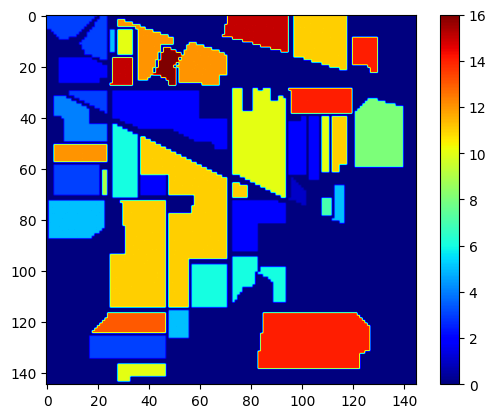

In [4]:
plt.imshow(y, cmap='jet')
plt.colorbar()

In [5]:
# Hyperspectral image
X = loadmat("indian_pines_corrected.mat")['indian_pines_corrected']

In [6]:
print(X.shape)

(145, 145, 200)


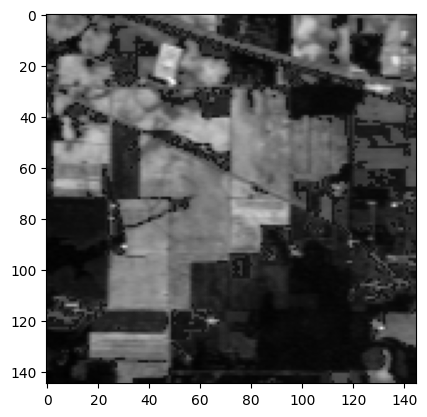

In [7]:
plt.imshow(X[:,:,25], cmap='gray')

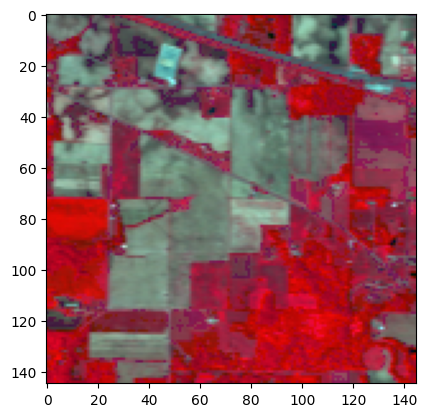

In [8]:
color_composite = np.stack([X[:, :, 50], X[:, :, 27], X[:, :, 17]], axis=-1)

# Simple min-max stretch per channel
def stretch(img):
    img = img.astype(np.float64)
    mn = img.min(axis=(0,1), keepdims=True)
    mx = img.max(axis=(0,1), keepdims=True)
    out = (img - mn) / (mx - mn + 1e-9)
    return np.clip(out, 0, 1)

plt.imshow(stretch(color_composite))

In [9]:
h, w, b = X.shape
X2d = X.reshape(h*w, b)

In [10]:
X2d.shape

(21025, 200)

In [11]:
wavelengths = np.linspace(400, 2500, 200)
band_names = [f"B{i+1}" for i, w in enumerate(wavelengths)]

In [12]:
df = pd.DataFrame(X2d, columns=band_names)
df

,B1,B2,B3,B4,B5,B6,B7,B8,B9,B10,...,B191,B192,B193,B194,B195,B196,B197,B198,B199,B200
0,3172,4142,4506,4279,4782,5048,5213,5106,5053,4750,...,1135,1094,1090,1112,1090,1062,1069,1057,1020,1020
1,2580,4266,4502,4426,4853,5249,5352,5353,5347,5065,...,1137,1108,1104,1117,1091,1079,1085,1064,1029,1020
2,3687,4266,4421,4498,5019,5293,5438,5427,5383,5132,...,1144,1111,1114,1114,1100,1065,1092,1061,1030,1016
3,2749,4258,4603,4493,4958,5234,5417,5355,5349,5096,...,1146,1122,1108,1109,1109,1071,1088,1060,1030,1006
4,2746,4018,4675,4417,4886,5117,5215,5096,5098,4834,...,1135,1110,1107,1112,1094,1072,1087,1052,1034,1019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21020,2561,3987,4011,4023,4201,4377,4418,4248,4180,3838,...,1021,1013,1012,1018,1015,1011,1001,1000,1009,1008
21021,2726,4104,4024,3880,4210,4377,4413,4174,4229,3900,...,1023,1012,1014,1012,1024,998,1010,1006,1000,1000
21022,3153,3864,4282,3889,4310,4372,4375,4208,4096,3878,...,1020,1016,1015,1016,1021,1008,1019,1003,1008,1000
21023,3155,4104,4106,4027,4139,4318,4413,4174,4140,3933,...,1015,1005,1011,1008,1012,1014,1007,1011,1005,1003


Text(0, 0.5, 'Reflectance')

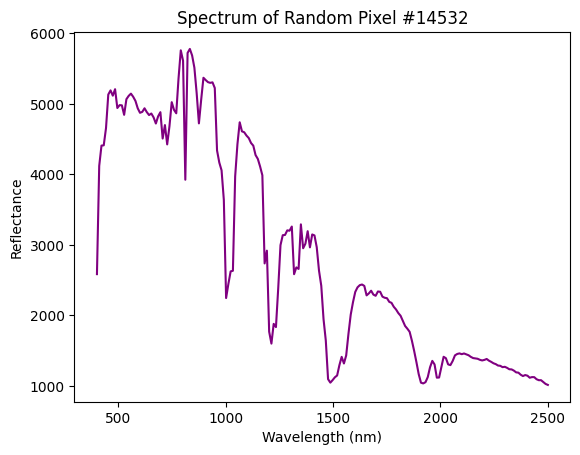

In [13]:
i = np.random.randint(0, X2d.shape[0])
spectrum = X2d[i, :]
plt.plot(wavelengths, spectrum, color='purple', lw=1.5)
plt.title(f"Spectrum of Random Pixel #{i}")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")


## Compute Indices

- **NDVI**  = (NIR - RED) / (NIR + RED)  
- **GNDVI** = (NIR - GREEN) / (NIR + GREEN)  
- **NDWI**  = (NIR - SWIR) / (NIR + SWIR)

In [14]:
RED_BAND   = 9
GREEN_BAND = 19
BLUE_BAND = 29
NIR_BAND   = 40
SWIR_BAND  = 95   # used for NDWI (NIR vs SWIR)

In [15]:
def safe_norm_diff(a, b, eps=1e-9):
    return (a - b) / (a + b + eps)

# Compute full-image indices then select valid pixels
nir   = X[:, :, NIR_BAND].astype(np.float64)
red   = X[:, :, RED_BAND].astype(np.float64)
green = X[:, :, GREEN_BAND].astype(np.float64)
swir  = X[:, :, SWIR_BAND].astype(np.float64)

NDVI  = safe_norm_diff(nir, red)
GNDVI = safe_norm_diff(nir, green)
NDWI  = safe_norm_diff(nir, swir)

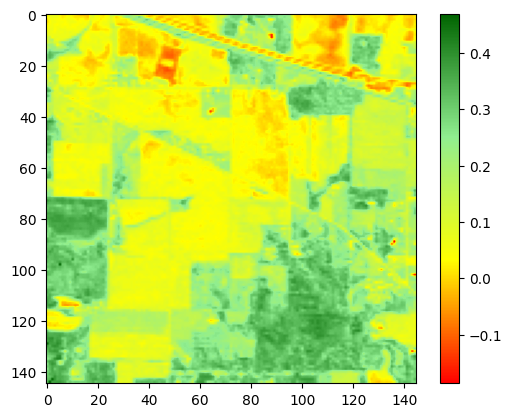

In [16]:
colors = ['red', 'yellow', 'lightgreen', 'darkgreen']
ndvi_cmap = LinearSegmentedColormap.from_list("custom", colors, N=256)

plt.imshow(NDVI, cmap=ndvi_cmap)
plt.colorbar()

In [17]:
# Stack indices as features for valid pixels
indices_stack = np.stack([NDVI, GNDVI, NDWI], axis=-1).reshape(h*w, 3)
indices_stack.shape

(21025, 3)

## K-Means on engineered Features 

In [18]:
k = 16  
clus_model = KMeans(n_clusters=k)
clus_model.fit(indices_stack)

lab_1 = clus_model.labels_
class_map_1 = lab_1.reshape((h,w,1))

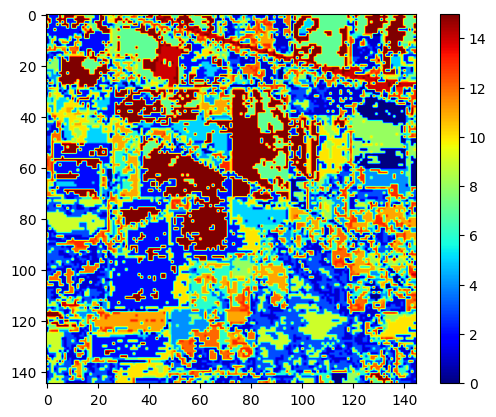

In [19]:
plt.imshow(class_map_1, cmap='jet')
plt.colorbar()

## PCA 

In [20]:
scaler = StandardScaler()
X2d_std = scaler.fit_transform(X2d)  # (n_valid, B)

In [21]:
n_pcs = 5  # feel free to tune
pca = PCA(n_components=n_pcs, random_state=42)
X2d_pcs = pca.fit_transform(X2d_std)

print("Explained variance (first 5 PCs):", np.round(pca.explained_variance_ratio_[:5], 4))
X2d_pcs.shape

Explained variance (first 5 PCs): [0.6862 0.1919 0.0256 0.0169 0.0105]


(21025, 5)

## K-Means on PCA Features 

In [22]:
clus_model = KMeans(n_clusters=k)
clus_model.fit(X2d_pcs)

lab_2 = clus_model.labels_
class_map_2 = lab_2.reshape((h,w,1))

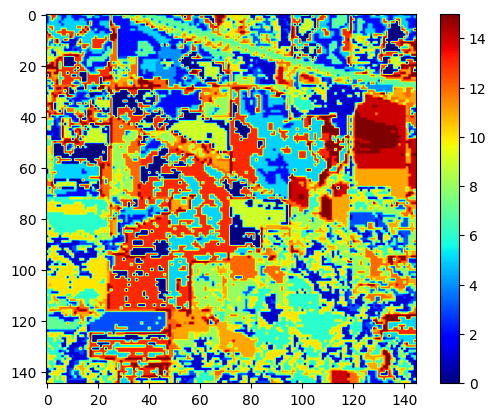

In [23]:
plt.imshow(class_map_2, cmap='jet')
plt.colorbar()

## Combine Features = [Indices | PCs]

In [24]:
feat_combined = np.hstack([indices_stack, X2d_pcs])
print("Combined feature shape:", feat_combined.shape)

Combined feature shape: (21025, 8)


## K-Means on Combined Features

In [25]:
clus_model = KMeans(n_clusters=k)
clus_model.fit(X2d_pcs)

lab_3 = clus_model.labels_
class_map_3 = lab_3.reshape((h,w,1))

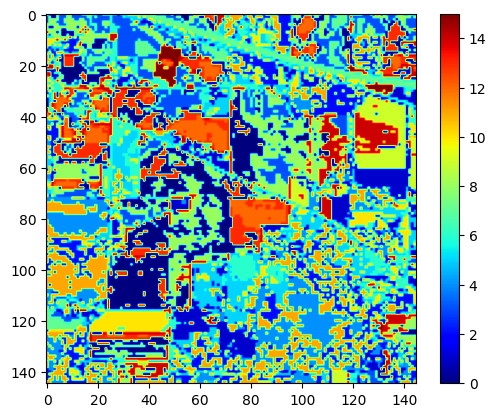

In [26]:
plt.imshow(class_map_3, cmap='jet')
plt.colorbar()